# Chapter 10. 분류 분석으로 주문 취소 여부 예측하기

- **목표**: 주문이 **취소(cancelled)될지 완료(completed)될지**를 예측하고, 그 모델을 실제로 써도 되는지 판단한다.
- **핵심 규칙**: 모델과 threshold는 **Validation**에서 고르고, **Final Test**는 모든 선택이 끝난 뒤 마지막에 한 번만 본다.
- **분류란?** 회귀는 "얼마?"(금액)를 맞히고, 분류는 "어느 쪽?"(취소/완료)을 맞힌다.

## STEP 0. 작업 환경과 입력 데이터 확인

- **목적**: 작업 폴더와 사용할 데이터 파일(`data/raw`의 orders, order_items, customers)이 있는지 확인한다.
- **비유**: 요리하기 전에 재료가 냉장고에 있는지 보는 단계다.

In [1]:
import sys
import logging
from pathlib import Path

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in ["notebooks", "chapter09", "chapter10"] else CURRENT_DIR

print("현재 폴더 이름:", CURRENT_DIR.name)
print("파이썬 버전:", sys.version.split()[0])

for name in ["orders.csv", "order_items.csv", "customers.csv"]:
    exists = (PROJECT_ROOT / "data" / "raw" / name).exists()
    print(name, "->", "있음" if exists else "없음")

현재 폴더 이름: chapter10
파이썬 버전: 3.11.15
orders.csv -> 있음
order_items.csv -> 있음
customers.csv -> 있음


### 결과 관찰
- 세 파일(orders, order_items, customers)이 모두 있다.

### 나의 판단
- 9장과 같은 공통 원본 `data/raw`를 입력으로 사용한다. 세 파일 모두 결측치와 중복 행이 없어서 추가 전처리 없이 쓸 수 있다.
- 가이드의 `scripts/prepare_ch10_data.py`, `scripts/run_classification_analysis.py`, `src/classification.py`는 프로젝트에 없어서, 같은 흐름을 노트북 셀로 구현하고 **Restart and Run All**로 재실행을 대체한다.

## STEP 1. Target Contract와 예측 시점 정의

- **무엇을 예측하는가?** 주문이 취소될지 여부
- **예측 단위**: 주문 1건
- **언제 예측하는가?** 주문이 생성된 직후
- **Target**: `is_cancelled` (completed = 0, cancelled = 1)
- **제외**: refunded와 기타 상태는 모델링 범위에서 뺀다.
- **알 수 있는 정보**: 주문 월·요일, 결제수단, 주문 상품 수·수량·금액, 고객 나이·성별·도시
- **쓰면 안 되는 정보**: `order_status`, `is_cancelled`, ID(`order_id`, `customer_id`, `product_id`), 취소 사유와 취소 시각 같은 사후 정보
- 파일에 있는 컬럼이라도 예측 시점에 알 수 없으면 feature로 쓰지 않는다.

In [2]:
import pandas as pd

RAW = PROJECT_ROOT / "data" / "raw"
orders = pd.read_csv(RAW / "orders.csv", encoding="utf-8-sig")
order_items = pd.read_csv(RAW / "order_items.csv", encoding="utf-8-sig")
customers = pd.read_csv(RAW / "customers.csv", encoding="utf-8-sig")

print("전체 주문 수:", len(orders))
print()
print("주문 상태별 건수")
print(orders["order_status"].value_counts())

# completed=0, cancelled=1 만 사용 (나머지 상태는 제외)
target_map = {"completed": 0, "cancelled": 1}
model_orders = orders[orders["order_status"].isin(target_map)].copy()
model_orders["is_cancelled"] = model_orders["order_status"].map(target_map)

print()
print("모델에 쓰는 주문 수:", len(model_orders))
print("제외된 주문 수 (refunded 등):", len(orders) - len(model_orders))

전체 주문 수: 300

주문 상태별 건수
order_status
completed    184
cancelled     64
refunded      52
Name: count, dtype: int64

모델에 쓰는 주문 수: 248
제외된 주문 수 (refunded 등): 52


### 결과 관찰
- 전체 주문 300건 중 completed 184건, cancelled 64건, refunded 52건이다.
- 모델링에 쓰는 주문은 completed와 cancelled를 합친 **248건**이고, refunded 52건은 제외했다.

### 나의 판단
- refunded는 취소와 다른 상태라서 섞으면 타깃의 의미가 흐려진다. 그래서 제외했다.
- 사용할 수 있는 주문이 248건으로 적어서, 이후 결과를 해석할 때 표본이 작다는 한계를 함께 기록한다.

## STEP 2. 주문 단위 특징과 계산 관계 검증

- **목적**: 예측 단위가 주문 1건이므로, 주문 상세(order_items)를 주문 1건당 1행으로 합친다.
- **만드는 특징**: `item_count`(담은 상품 수), `total_quantity`(총 수량), `order_amount`(주문 금액)
- **먼저 검증**: `line_total = quantity × unit_price`를 직접 계산해 합계가 맞는지 확인한다.
- **비유**: 영수증의 줄별 금액을 모아서 주문 한 장으로 요약하는 단계다.

In [3]:
# 1) 원본 데이터 상태 확인 (결측, 중복, 값 범위)
print("결측치 (orders / order_items / customers):",
      int(orders.isna().sum().sum()), "/", int(order_items.isna().sum().sum()), "/", int(customers.isna().sum().sum()))
print("완전 중복 행 (orders / order_items / customers):",
      int(orders.duplicated().sum()), "/", int(order_items.duplicated().sum()), "/", int(customers.duplicated().sum()))

# 2) line_total = quantity x unit_price 를 직접 계산
order_items["line_total"] = order_items["quantity"] * order_items["unit_price"]

# 3) 주문 1건 = 1행으로 집계
order_features = (
    order_items.groupby("order_id")
    .agg(item_count=("order_item_id", "count"),
         total_quantity=("quantity", "sum"),
         order_amount=("line_total", "sum"))
    .reset_index()
)

# 4) 계산 관계 검증
checks = pd.DataFrame([
    ("quantity > 0", bool((order_items["quantity"] > 0).all())),
    ("unit_price > 0", bool((order_items["unit_price"] > 0).all())),
    ("order_id당 주문 특징 1행", bool(order_features["order_id"].is_unique)),
    ("주문 금액 합계 일치",
     bool(order_features["order_amount"].sum() == (order_items["quantity"] * order_items["unit_price"]).sum())),
], columns=["check", "passed"])
checks["status"] = checks["passed"].map({True: "PASS", False: "FAIL"})
print()
print(checks[["check", "status"]].to_string(index=False))
print()
print("주문 특징 행 수:", len(order_features))
print(order_features[["item_count", "total_quantity", "order_amount"]].describe().round(0).to_string())

결측치 (orders / order_items / customers): 0 / 0 / 0
완전 중복 행 (orders / order_items / customers): 0 / 0 / 0

             check status
      quantity > 0   PASS
    unit_price > 0   PASS
order_id당 주문 특징 1행   PASS
       주문 금액 합계 일치   PASS

주문 특징 행 수: 300
       item_count  total_quantity  order_amount
count       300.0           300.0         300.0
mean          3.0             8.0      852033.0
std           1.0             4.0      515967.0
min           1.0             1.0       10000.0
25%           2.0             5.0      413750.0
50%           3.0             7.0      807000.0
75%           3.0            11.0     1173000.0
max           4.0            19.0     2821000.0


### 결과 관찰
- 세 원본 파일 모두 결측치와 완전 중복 행이 없다.
- 검증 4개(수량 > 0, 단가 > 0, 주문당 1행, 금액 합계 일치)가 모두 PASS다.

### 나의 판단
- 계산 관계가 맞으므로 주문 금액을 믿고 feature로 사용한다.

## STEP 3. 병합 관계와 Feature Audit

- **목적**: 주문, 주문 특징, 고객 정보를 합칠 때 행이 늘거나 사라지지 않았는지 확인한다.
- **기대 관계**: 주문 1 ↔ 1 주문 특징, 주문 여러 건 → 고객 1명
- **Feature Audit**: 쓸 feature와 금지 컬럼이 겹치지 않는지 확인한다.
- **원칙**: 미매칭을 이유 확인 없이 0으로 채워 숨기지 않는다.

In [4]:
# 1) 주문 + 주문 특징 (1 대 1)
n_before = len(model_orders)
merged = model_orders.merge(order_features, on="order_id", how="left", validate="one_to_one")
unmatched_items = int(merged["item_count"].isna().sum())

# 2) 주문 + 고객 (여러 주문 대 고객 1명)
merged = merged.merge(customers[["customer_id", "gender", "age", "city"]],
                      on="customer_id", how="left", validate="many_to_one")
unmatched_customers = int(merged["age"].isna().sum())

print("병합 전 행 수:", n_before)
print("병합 후 행 수:", len(merged))
print("주문 특징 미매칭:", unmatched_items)
print("고객 정보 미매칭:", unmatched_customers)

# 3) 주문 시점에 알 수 있는 날짜 정보 만들기
merged["order_date"] = pd.to_datetime(merged["order_date"])
merged["order_month_num"] = merged["order_date"].dt.month
merged["order_dayofweek"] = merged["order_date"].dt.dayofweek

# 4) Feature Audit: 쓸 feature와 금지 feature
numeric_features = ["item_count", "total_quantity", "order_amount", "order_month_num", "order_dayofweek", "age"]
categorical_features = ["payment_method", "gender", "city"]
feature_columns = numeric_features + categorical_features
forbidden = ["order_status", "is_cancelled", "order_id", "customer_id", "product_id", "order_item_id", "order_date"]

print()
print("사용 feature:", feature_columns)
print("금지 컬럼과 겹치는 feature:", sorted(set(feature_columns) & set(forbidden)) or "없음")
print("필수 feature 결측:", int(merged[feature_columns].isna().sum().sum()))

병합 전 행 수: 248
병합 후 행 수: 248
주문 특징 미매칭: 0
고객 정보 미매칭: 0

사용 feature: ['item_count', 'total_quantity', 'order_amount', 'order_month_num', 'order_dayofweek', 'age', 'payment_method', 'gender', 'city']
금지 컬럼과 겹치는 feature: 없음
필수 feature 결측: 0


### 결과 관찰
- 병합 전후 행 수가 248건으로 같고, 주문 특징과 고객 정보 미매칭은 모두 0건이다.
- 사용 feature는 9개(숫자 6개, 범주 3개)이고, 금지 컬럼과 겹치는 것은 없다.

### 나의 판단
- `order_status`, ID, `order_date`는 feature에서 뺐다. `order_date`는 월과 요일을 만드는 재료로만 쓴다.
- 9장에서는 `order_amount`, `quantity` 같은 금액 계산 재료가 정답과 직결되어 제외했다. 이번에는 정답이 취소 여부이고 이 값들은 주문 시점에 알 수 있어서 사용한다.

## STEP 4. 클래스 분포 확인

- **목적**: 취소와 완료가 얼마나 균형 잡혀 있는지 본다.
- **왜 중요한가?** 한쪽이 훨씬 많으면, 무조건 많은 쪽만 찍어도 accuracy가 높게 나오기 때문이다.

                건수  비율(%)
completed (0)  184   74.2
cancelled (1)   64   25.8

취소 비율: 25.8 %
항상 completed로 찍으면 정확도: 74.2 %


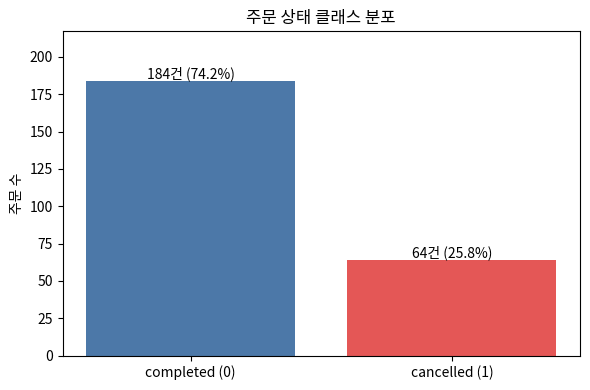

저장 완료: chapter10/images/step02_class_ratio.png


In [5]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans CJK JP"]
plt.rcParams["axes.unicode_minus"] = False
IMAGE_DIR = PROJECT_ROOT / "chapter10" / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

counts = merged["is_cancelled"].value_counts().sort_index()
ratio = (counts / counts.sum() * 100).round(1)
class_table = pd.DataFrame({"건수": counts.values, "비율(%)": ratio.values},
                           index=["completed (0)", "cancelled (1)"])
print(class_table)
print()
print("취소 비율:", ratio[1], "%")
print("항상 completed로 찍으면 정확도:", ratio[0], "%")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["completed (0)", "cancelled (1)"], counts.values, color=["#4c78a8", "#e45756"])
for b, r in zip(bars, ratio.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 2, f"{int(b.get_height())}건 ({r}%)", ha="center")
ax.set_title("주문 상태 클래스 분포")
ax.set_ylabel("주문 수")
ax.set_ylim(0, counts.max() * 1.18)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "step02_class_ratio.png", dpi=150)
plt.show()
print("저장 완료: chapter10/images/step02_class_ratio.png")

### 결과 관찰
- completed 184건(74.2%), cancelled 64건(25.8%)이다.
- 모든 주문을 completed로 찍기만 해도 accuracy가 74.2%가 나온다.

### 나의 해석과 판단
- 클래스가 불균형(취소가 약 4분의 1)이라서 **accuracy만으로는 좋은 모델인지 알 수 없다.** Precision, Recall, F1을 함께 본다.
- 이 기준선이 바로 Dummy baseline이다. 실제 모델은 취소를 얼마나 더 잡아내는지로 평가한다.

## STEP 5. Train / Validation / Test 나누기

- **Train (60%)**: 모델이 배우는 데이터
- **Validation (20%)**: 모델과 threshold를 고르는 데이터
- **Test (20%)**: 모든 선택이 끝난 뒤 마지막에 한 번만 쓰는 데이터
- 취소 비율이 세 구간에서 비슷하도록 stratified 방식으로 나눈다. (`random_state=42`)
- **비유**: 연습 문제(Train), 모의고사(Validation), 실제 시험(Test)이다.

In [6]:
from sklearn.model_selection import train_test_split

X = merged[feature_columns]
y = merged["is_cancelled"]

# 1) Test 20% 먼저 떼어 두기 (클래스 비율 유지)
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
# 2) 나머지에서 Validation 25% (전체의 20%)
X_train, X_val, y_train, y_val = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=42)

split_summary = pd.DataFrame({
    "행 수": [len(y_train), len(y_val), len(y_test)],
    "completed": [int((y_train == 0).sum()), int((y_val == 0).sum()), int((y_test == 0).sum())],
    "cancelled": [int((y_train == 1).sum()), int((y_val == 1).sum()), int((y_test == 1).sum())],
    "취소 비율(%)": [round(y_train.mean() * 100, 1), round(y_val.mean() * 100, 1), round(y_test.mean() * 100, 1)],
}, index=["Train", "Validation", "Test"])
print(split_summary)
print()
print("세 구간 모두 두 클래스 존재:", all(s.nunique() == 2 for s in [y_train, y_val, y_test]))

            행 수  completed  cancelled  취소 비율(%)
Train       148        110         38      25.7
Validation   50         37         13      26.0
Test         50         37         13      26.0

세 구간 모두 두 클래스 존재: True


### 결과 관찰
- Train 148건, Validation 50건, Test 50건이다.
- 세 구간의 취소 비율이 약 26%로 비슷하고, 모두 두 클래스를 포함한다.

### 한계와 추가 확인 사항
- 이번 분할은 교육용 **random split**이다. 실제로 미래 주문을 예측하려면 시간 순서로 나눈 out-of-time 평가가 필요하다.
- Validation과 Test의 취소 주문이 각각 13건뿐이라서, 결과가 몇 건만 바뀌어도 크게 흔들릴 수 있다.

## STEP 6. Pipeline 전처리

- **숫자형**: 빈칸은 중앙값으로 채우고(median) → 크기를 맞춘다(StandardScaler)
- **범주형**: 빈칸은 가장 흔한 값으로 채우고(most_frequent) → 0/1 열로 바꾼다(OneHotEncoder)
- **핵심**: 전처리 규칙은 **Train으로만** 배우고, Validation과 Test에는 그 규칙만 적용한다. (전체 데이터로 미리 배우면 시험 문제를 미리 보는 것과 같다.)

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def make_preprocessor():
    numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                             ("scaler", StandardScaler())])
    categorical_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                 ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer([("num", numeric_pipe, numeric_features),
                              ("cat", categorical_pipe, categorical_features)])

# 전처리 규칙은 Train으로만 학습하고, Validation과 Test에는 규칙만 적용한다
check_prep = make_preprocessor().fit(X_train)
X_train_t = check_prep.transform(X_train)
X_val_t = check_prep.transform(X_val)
print("Train 변환 후 모양:", X_train_t.shape)
print("Validation 변환 후 모양:", X_val_t.shape)
print("열 개수 동일:", X_train_t.shape[1] == X_val_t.shape[1])

Train 변환 후 모양: (148, 22)
Validation 변환 후 모양: (50, 22)
열 개수 동일: True


### 결과 관찰
- 전처리 후 Train은 (148, 22), Validation은 (50, 22)로 열 개수가 같다.

### 나의 판단
- Train으로만 규칙을 학습했고 Validation에는 적용만 했으므로 전처리 누수는 없다.

## STEP 7. Validation에서 후보 모델 비교

- **후보**: Dummy(항상 completed로 찍기), Logistic Regression, Random Forest
- **지표**: Accuracy(전체 정답률), Precision(취소라고 한 것 중 실제 취소), Recall(실제 취소 중 잡아낸 비율), F1(Precision과 Recall의 균형)
- **선택 규칙**: Dummy를 뺀 모델 중 F1 → Recall → Precision 순으로 비교해서 고른다. Test는 아직 보지 않는다.

                     Accuracy  Precision  Recall     F1
모델                                                     
Dummy                    0.74        0.0   0.000  0.000
Logistic Regression      0.76        0.6   0.231  0.333
Random Forest            0.74        0.5   0.077  0.133

Validation에서 선택한 모델: Logistic Regression


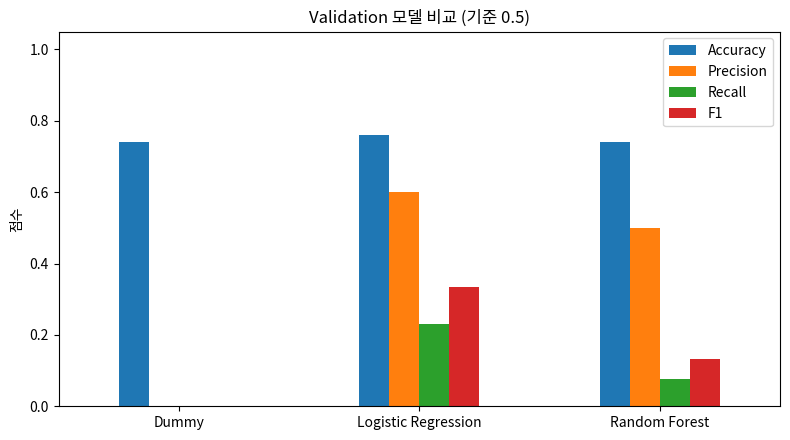

저장 완료: chapter10/images/step03_baseline.png


In [8]:
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

candidates = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

def calc_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

fitted_models = {}
rows = []
for name, model in candidates.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", model)])
    pipe.fit(X_train, y_train)          # Train으로만 학습
    fitted_models[name] = pipe
    m = calc_metrics(y_val, pipe.predict(X_val))   # Validation 평가 (기본 기준 0.5)
    m["모델"] = name
    rows.append(m)

val_compare = pd.DataFrame(rows).set_index("모델").round(3)
print(val_compare)

# 선택 규칙: Dummy 제외, F1 -> Recall -> Precision 순으로 비교
non_base = val_compare.drop(index="Dummy")
selected_model_name = non_base.sort_values(["F1", "Recall", "Precision"], ascending=False).index[0]
print()
print("Validation에서 선택한 모델:", selected_model_name)

fig, ax = plt.subplots(figsize=(8, 4.5))
val_compare[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", ax=ax, rot=0)
ax.set_title("Validation 모델 비교 (기준 0.5)")
ax.set_ylabel("점수")
ax.set_ylim(0, 1.05)
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "step03_baseline.png", dpi=150)
plt.show()
print("저장 완료: chapter10/images/step03_baseline.png")

### 결과 관찰
- Dummy는 accuracy 0.74지만 취소를 하나도 못 잡는다(Recall 0).
- Logistic Regression은 F1 0.333(Precision 0.6, Recall 0.231), Random Forest는 F1 0.133(Recall 0.077)이다.
- Validation 기준으로 **Logistic Regression**이 선택되었다.

### 나의 해석과 판단
- 두 모델 모두 취소 주문의 대부분을 놓친다. 그래도 Dummy와 달리 취소를 일부라도 잡아낸다.
- Random Forest는 Recall이 0.077로 취소를 거의 잡지 못했다. 데이터가 248건으로 적어서 복잡한 모델이 유리하지 않았을 수 있다(가설).

## STEP 8. Validation에서 Threshold 선택

- **threshold란?** 취소 확률이 몇 이상이면 "취소 위험"으로 판단할지 정하는 기준값이다.
- **낮추면**: 취소를 더 많이 잡지만(Recall ↑) 잘못 의심하는 것도 늘어난다(FP ↑).
- **높이면**: 확실한 것만 취소로 판단해 정확해지지만(Precision ↑) 놓치는 취소가 늘어난다(FN ↑).
- **선택 규칙**: Validation에서 F1 → Recall → Precision 순으로 비교한다.

           Precision  Recall     F1  예측한 취소 건수
threshold                                     
0.10           0.271   1.000  0.426         48
0.15           0.286   0.923  0.436         42
0.20           0.275   0.846  0.415         40
0.25           0.303   0.769  0.435         33
0.30           0.364   0.615  0.457         22
0.35           0.429   0.462  0.444         14
0.40           0.500   0.385  0.435         10
0.45           0.714   0.385  0.500          7
0.50           0.600   0.231  0.333          5
0.55           1.000   0.154  0.267          2
0.60           1.000   0.154  0.267          2
0.65           1.000   0.077  0.143          1
0.70           1.000   0.077  0.143          1
0.75           0.000   0.000  0.000          0
0.80           0.000   0.000  0.000          0
0.85           0.000   0.000  0.000          0
0.90           0.000   0.000  0.000          0

Validation에서 선택한 threshold: 0.45


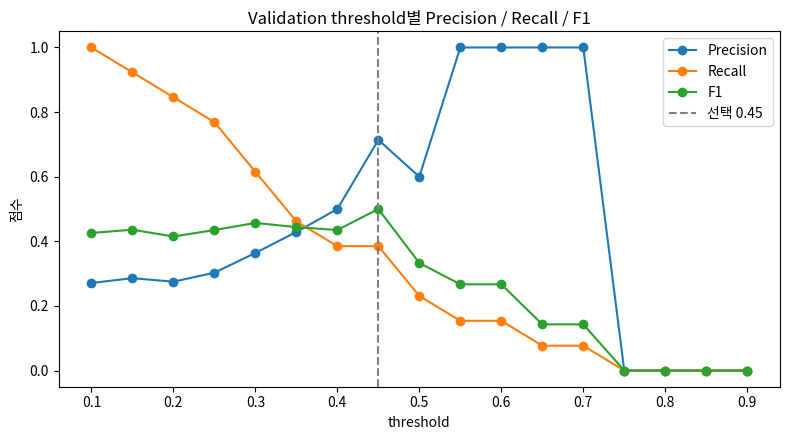

저장 완료: chapter10/images/step05_threshold.png


In [9]:
selected_pipe = fitted_models[selected_model_name]
val_proba = selected_pipe.predict_proba(X_val)[:, 1]

thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
rows = []
for t in thresholds:
    pred = (val_proba >= t).astype(int)
    m = calc_metrics(y_val, pred)
    m["threshold"] = t
    m["예측한 취소 건수"] = int(pred.sum())
    rows.append(m)

threshold_table = pd.DataFrame(rows).set_index("threshold").round(3)
print(threshold_table[["Precision", "Recall", "F1", "예측한 취소 건수"]])

# 선택 규칙: F1 -> Recall -> Precision 순
best = threshold_table.sort_values(["F1", "Recall", "Precision"], ascending=False)
selected_threshold = float(best.index[0])
print()
print("Validation에서 선택한 threshold:", selected_threshold)

fig, ax = plt.subplots(figsize=(8, 4.5))
for col in ["Precision", "Recall", "F1"]:
    ax.plot(threshold_table.index, threshold_table[col], marker="o", label=col)
ax.axvline(selected_threshold, color="gray", linestyle="--", label=f"선택 {selected_threshold}")
ax.set_title("Validation threshold별 Precision / Recall / F1")
ax.set_xlabel("threshold")
ax.set_ylabel("점수")
ax.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "step05_threshold.png", dpi=150)
plt.show()
print("저장 완료: chapter10/images/step05_threshold.png")

### 결과 관찰
- threshold 0.10에서는 Recall이 1.0이지만 Precision이 0.271로 낮고, 50건 중 48건을 취소로 의심한다.
- threshold 0.55 이상에서는 Precision이 1.0이지만 Recall이 0.154 이하로 떨어진다.
- F1이 가장 높은 threshold는 **0.45**(Precision 0.714, Recall 0.385, F1 0.5)이다.

### 나의 해석과 판단 (관찰과 가설 구분)
- 관찰: threshold를 낮추면 Recall이 오르고 예측한 취소 건수와 FP도 함께 늘었다.
- 가설: 취소를 더 많이 잡으려면 잘못 의심하는 주문이 늘어나는 비용을 감수해야 할 수 있다.
- 0.45는 F1 기준의 자동 선택이다. 실제 업무에서 취소를 놓치는 비용과 잘못 의심하는 비용이 다르면 다른 값을 고를 수 있다.
- Validation의 취소 주문이 13건뿐이라 이 선택도 우연의 영향을 받을 수 있다.

## STEP 9. 모델과 Threshold 고정 후 Final Test

- Validation에서 고른 **모델과 threshold를 여기서 고정**한다.
- Final Test에서는 Dummy와 고정한 모델만 평가한다.
- 결과가 기대보다 낮아도 Test를 보면서 모델이나 threshold를 다시 고르지 않는다.

In [10]:
# 여기서부터 모델과 threshold는 바꾸지 않는다 (고정)
FROZEN_MODEL_NAME = selected_model_name
FROZEN_THRESHOLD = selected_threshold
print("고정한 모델:", FROZEN_MODEL_NAME)
print("고정한 threshold:", FROZEN_THRESHOLD)

# Final Test: Dummy와 고정한 모델만 평가
test_proba = fitted_models[FROZEN_MODEL_NAME].predict_proba(X_test)[:, 1]
test_pred = (test_proba >= FROZEN_THRESHOLD).astype(int)
dummy_pred = fitted_models["Dummy"].predict(X_test)

test_compare = pd.DataFrame({
    "Dummy": calc_metrics(y_test, dummy_pred),
    FROZEN_MODEL_NAME: calc_metrics(y_test, test_pred),
}).T.round(3)
print()
print("Final Test 결과 (행 수:", len(y_test), ")")
print(test_compare)

고정한 모델: Logistic Regression
고정한 threshold: 0.45

Final Test 결과 (행 수: 50 )
                     Accuracy  Precision  Recall     F1
Dummy                    0.74      0.000   0.000  0.000
Logistic Regression      0.72      0.444   0.308  0.364


### 결과 관찰 (Final Test 50건, 취소 13건)
| 모델 | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Dummy | 0.74 | 0.000 | 0.000 | 0.000 |
| Logistic Regression (threshold 0.45) | 0.72 | 0.444 | 0.308 | 0.364 |

### 나의 해석과 판단
- 선택 모델은 Dummy와 달리 취소를 일부 잡아낸다(Recall 0.308, F1 0.364). 하지만 **Accuracy는 Dummy(0.74)보다 낮다(0.72).**
- Validation의 F1(0.5)보다 Test의 F1(0.364)이 낮다. Validation에서 고른 threshold가 조금 낙관적이었다는 뜻이다.
- 취소를 놓치지 않는 것이 목적이라면 Recall 0.308은 부족하다.

## STEP 10. Confusion Matrix와 FP/FN 해석

- **TN**: 완료를 완료로 맞힘
- **FP**: 완료인데 취소 위험으로 잘못 의심함
- **FN**: 취소인데 완료로 잘못 판단해 놓침
- **TP**: 취소를 취소 위험으로 맞힘

TN (완료를 완료로 예측): 32
FP (완료를 취소 위험으로 예측): 5
FN (취소를 완료로 예측): 9
TP (취소를 취소 위험으로 예측): 4

실제 취소 주문 중 잡아낸 비율 (Recall): 0.308
취소 위험이라 예측한 것 중 실제 취소 비율 (Precision): 0.444


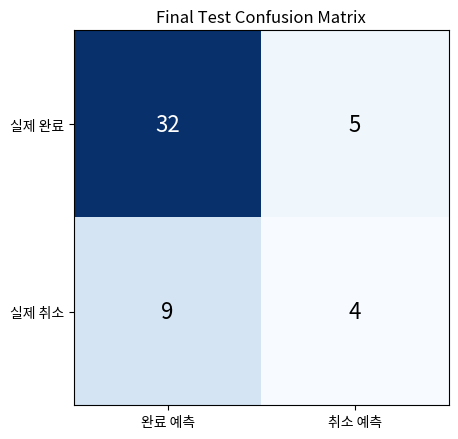

저장 완료: chapter10/images/step06_confusion_matrix.png


In [11]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, test_pred, labels=[0, 1]).ravel()
print("TN (완료를 완료로 예측):", tn)
print("FP (완료를 취소 위험으로 예측):", fp)
print("FN (취소를 완료로 예측):", fn)
print("TP (취소를 취소 위험으로 예측):", tp)
print()
print("실제 취소 주문 중 잡아낸 비율 (Recall):", round(tp / (tp + fn), 3))
print("취소 위험이라 예측한 것 중 실제 취소 비율 (Precision):", round(tp / (tp + fp), 3) if (tp + fp) else "예측한 취소 없음")

cm = np.array([[tn, fp], [fn, tp]])
fig, ax = plt.subplots(figsize=(5.2, 4.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["완료 예측", "취소 예측"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["실제 완료", "실제 취소"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_title("Final Test Confusion Matrix")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "step06_confusion_matrix.png", dpi=150)
plt.show()
print("저장 완료: chapter10/images/step06_confusion_matrix.png")

### 결과 관찰
| | 완료 예측 | 취소 예측 |
|---|---|---|
| 실제 완료 | TN 32 | FP 5 |
| 실제 취소 | FN 9 | TP 4 |

- 실제 취소 13건 중 4건만 잡고 9건을 놓쳤다. 취소 위험이라고 한 9건 중 실제 취소는 4건이다.

### 나의 해석과 판단
- **FP의 비용**: 정상 주문을 취소 위험으로 의심해 불필요한 확인이나 안내 비용이 생길 수 있다.
- **FN의 비용**: 취소될 주문을 놓쳐 재고, 배송, 매출 계획에 차질이 생길 수 있다.
- 이번 결과는 FN이 FP보다 많다. 취소 대응이 목적이라면 FN을 더 중요하게 볼 가능성이 높다.

### 한계와 추가 확인 사항
- 이 데이터로는 FP와 FN의 실제 비용을 알 수 없다. 두 비용의 크기를 업무 담당자에게 확인해야 threshold를 확정할 수 있다.

## STEP 11. Internal 결과와 Public 결과 구분

- **Internal**: 오류 분석용으로 `order_id` 같은 식별자가 필요할 수 있다. 공개하지 않는다.
- **Public**: 식별자를 빼고, 새로 붙인 `record_id`, 실제값, 예측값, 취소 확률, 모델, threshold만 남긴다.
- 성능이 좋은지 확인하는 것과, 공개해도 되는지 확인하는 것은 별개의 검토다.

In [12]:
# 공개용 예측 결과: 원본 식별자 없이, 새로 붙인 record_id만 사용
public_pred = pd.DataFrame({
    "record_id": range(1, len(y_test) + 1),
    "actual_is_cancelled": y_test.values,
    "predicted_is_cancelled": test_pred,
    "cancel_probability": test_proba.round(3),
    "model": FROZEN_MODEL_NAME,
    "threshold": FROZEN_THRESHOLD,
})

banned = ["source_index", "order_id", "customer_id", "product_id"]
print("공개 결과 컬럼:", list(public_pred.columns))
print("금지 컬럼 포함 여부:", [c for c in banned if c in public_pred.columns] or "없음")
print()
print(public_pred.head(5).to_string(index=False))

공개 결과 컬럼: ['record_id', 'actual_is_cancelled', 'predicted_is_cancelled', 'cancel_probability', 'model', 'threshold']
금지 컬럼 포함 여부: 없음

 record_id  actual_is_cancelled  predicted_is_cancelled  cancel_probability               model  threshold
         1                    0                       0               0.134 Logistic Regression       0.45
         2                    0                       0               0.194 Logistic Regression       0.45
         3                    0                       0               0.268 Logistic Regression       0.45
         4                    0                       0               0.138 Logistic Regression       0.45
         5                    0                       0               0.378 Logistic Regression       0.45


### 결과 관찰
- 공개용 예측 결과는 6개 컬럼(`record_id`, `actual_is_cancelled`, `predicted_is_cancelled`, `cancel_probability`, `model`, `threshold`)이고, 금지 컬럼(`source_index`, `order_id`, `customer_id`, `product_id`)은 없다.

### 나의 판단
- `record_id`는 원본 주문 번호가 아니라 1번부터 새로 붙인 번호라서 원본 주문을 알아낼 수 없다.

## STEP 12. Validation Evidence 확인

- **목적**: 분석이 규칙을 지켰는지 8가지 계약을 코드로 점검한다. (최종 검수)

In [13]:
validation_checks = pd.DataFrame([
    ("binary_target_contract", set(y.unique()) == {0, 1}),
    ("forbidden_feature_overlap", len(set(feature_columns) & set(forbidden)) == 0),
    ("strict_merge_contract", len(merged) == n_before and unmatched_items == 0 and unmatched_customers == 0),
    ("all_splits_have_two_classes", all(s.nunique() == 2 for s in [y_train, y_val, y_test])),
    ("selected_model_from_validation", FROZEN_MODEL_NAME == selected_model_name and FROZEN_MODEL_NAME in non_base.index),
    ("selected_threshold_from_validation", FROZEN_THRESHOLD in list(threshold_table.index)),
    ("public_prediction_privacy", not any(c in public_pred.columns for c in banned)),
    ("test_rows_for_metrics", len(y_test) == len(test_pred) and len(y_test) > 0),
], columns=["check", "passed"])
validation_checks["status"] = validation_checks["passed"].map({True: "PASS", False: "FAIL"})
print(validation_checks[["check", "status"]].to_string(index=False))
print()
print("전체 PASS 여부:", bool(validation_checks["passed"].all()))

                             check status
            binary_target_contract   PASS
         forbidden_feature_overlap   PASS
             strict_merge_contract   PASS
       all_splits_have_two_classes   PASS
    selected_model_from_validation   PASS
selected_threshold_from_validation   PASS
         public_prediction_privacy   PASS
             test_rows_for_metrics   PASS

전체 PASS 여부: True


### 결과 관찰
- 8개 항목(타깃 계약, 금지 feature 겹침, 병합 계약, 세 구간 두 클래스, Validation 모델 선택, Validation threshold 선택, 공개 결과 식별자, Test 행 수)이 모두 **PASS**다.

### 한계
- 자동 PASS는 코드 규칙을 지켰다는 뜻이다. 운영에 써도 될 만큼 성능이 좋다는 뜻은 아니다. 공정성과 시간에 따른 성능 변화도 증명하지 않는다.

## STEP 13. 전체 재실행 확인

- 가이드의 스크립트가 프로젝트에 없어서, 노트북 셀로 구현하고 **Restart and Run All**로 재실행을 대체했다.
- 커널을 재시작하고 처음부터 끝까지 실행했을 때 오류 없이 완료되었고, 같은 결과가 나왔다.
- 결과가 재현되는 이유는 `random_state=42`로 분할과 모델을 고정했고, 데이터와 규칙이 같기 때문이다.

## STEP 14. LLM 검토와 최종 사용 판단

### LLM 활용 기록
- **사용 목적**: 타깃과 feature 설계 검토, 분류 코드 초안, 지표 해석 검토, 개념 학습
- **LLM에 준 계약**: 타깃 정의, 예측 시점, 허용/금지 feature, Train/Validation/Test 역할, Validation 선택 규칙, Final Test 보호 규칙, Privacy-safe Output 규칙
- **검토하며 확인한 점**: `order_status` 사용 금지, Test에서 모델·threshold 선택 금지, 전처리는 Train으로만 학습, 미매칭을 0으로 숨기지 않기, 예측 패턴을 원인으로 단정하지 않기
- **가이드와 다르게 한 점**: 프로젝트에 없는 scripts와 `src/classification.py` 대신 노트북 셀로 구현했다.
- **최종 판단은 누가 했는가**: 분석자인 내가 Evidence를 확인한 뒤 결정했다.

In [14]:
baseline_acc = round(test_compare.loc["Dummy", "Accuracy"], 3)
model_acc = round(test_compare.loc[FROZEN_MODEL_NAME, "Accuracy"], 3)
print("Dummy Accuracy:", baseline_acc, "| 선택 모델 Accuracy:", model_acc)
print("Dummy Recall:", round(test_compare.loc["Dummy", "Recall"], 3),
      "| 선택 모델 Recall:", round(test_compare.loc[FROZEN_MODEL_NAME, "Recall"], 3))
print("Dummy F1:", round(test_compare.loc["Dummy", "F1"], 3),
      "| 선택 모델 F1:", round(test_compare.loc[FROZEN_MODEL_NAME, "F1"], 3))

Dummy Accuracy: 0.74 | 선택 모델 Accuracy: 0.72
Dummy Recall: 0.0 | 선택 모델 Recall: 0.308
Dummy F1: 0.0 | 선택 모델 F1: 0.364


## 최종 사용 판단

- **현재 사용 보류**

### 판단 근거
1. **클래스 비율**: 취소 25.8%, 완료 74.2%로 불균형이라 accuracy만으로 판단할 수 없다.
2. **Dummy 대비 개선**: 선택 모델은 취소를 일부 잡는다(Recall 0.308, F1 0.364). 하지만 Accuracy는 Dummy(0.74)보다 낮은 0.72다.
3. **Precision / Recall / F1**: Precision 0.444, Recall 0.308이라서, 실제 취소 13건 중 9건을 놓치고 취소로 의심한 9건 중 5건은 잘못된 의심이다.
4. **FP/FN 비용 가정**: 실제 비용을 알 수 없다. 취소 대응이 목적이면 FN(놓침)이 더 중요할 가능성이 있다.
5. **Threshold 선택 이유**: Validation의 F1이 가장 높은 0.45를 선택했다. Test의 F1(0.364)이 Validation(0.5)보다 낮아 선택이 낙관적이었다.
6. **Random split 한계**: 시간 순서가 아닌 무작위 분할이라 실제 미래 주문 예측 성능을 보장하지 못한다.
7. **표본 크기**: Test 50건 중 취소가 13건뿐이라 결과가 불안정하다.
8. **Privacy-safe Output**: 공개 결과에서 `order_id`, `customer_id`, `product_id`를 제거했고 검증도 PASS다.

### 추가로 필요한 것
- 더 많은 주문 데이터, 시간 순서 평가(out-of-time), 취소를 설명하는 추가 정보(예: 배송 정보, 프로모션 여부), FP와 FN의 업무 비용 확인

## 최종 제출 체크리스트

- [x] completed=0, cancelled=1만 사용했다. refunded는 제외했다.
- [x] 예측 시점(주문 생성 직후)을 설명했다.
- [x] target, ID, 사후 정보를 feature에서 제외했다.
- [x] `line_total = quantity × unit_price`를 검증했다.
- [x] 주문 단위 특징과 병합 관계를 검증했다.
- [x] 클래스 비율을 확인하고 Dummy baseline과 비교했다.
- [x] Train / Validation / Test 역할을 구분했다.
- [x] 전처리를 Pipeline 안에서 Train으로 학습했다.
- [x] 모델과 threshold를 Validation에서 선택하고, Final Test 전에 고정했다.
- [x] Accuracy, Precision, Recall, F1을 함께 해석했다.
- [x] FP/FN의 업무적 의미를 작성했다.
- [x] 공개 결과에 원본 식별자가 없음을 확인했다.
- [x] Validation Evidence 8개가 모두 PASS다.
- [x] Random split의 교육용 한계를 기록했다.
- [x] 최종 사용 판단과 한계를 작성했다.